# Linear Regression from scratch

reference = https://github.com/tugot17/Linear-Regression-From-Scratch/blob/master/LinearRegression.ipynb

### Problem

Given a Data set D={(x,y)} we need to predict y for new unseen x. 
\
Basically we want to predict a function that follows pattern similar to what x follows in given dataset.

In [1]:
import numpy as np # for numerical operations

### Design Matrix

**Why ?**  
Lets say we have data x train in the form ($x$ and $y$)

<div style="text-align: left;">
  <img src="image.png" width="400"/>
</div>

Area (input feature)  
Rooms (prediction)

A design matrix of a sample data is a matrix whose:

- rows are data points (samples)  
- cols are features  

Inorder to make data matrix representable so that we can do efficient matrix multiplication we have these Design Matrix  

so the above samples can be represented as  

$\begin{bmatrix}
1 & 1000 \\
1 & 1500 \\
1 & 2000
\end{bmatrix}$

Now if degree of polynomial is 2 then this Design Matrix becomes  

$\begin{bmatrix}
1 & x_{1} & (x_{1})^2 \\
1 & x_{2} & (x_{2})^2 \\
1 & x_{3} & (x_{3})^2
\end{bmatrix}$

basically its pow(ele,col) (col = 0 to n-1)

for all $x_1=1000, x_2=1500, x_3=2000$ are sample data  

so now if our function is of degree 2 ($M = 2$)  

$y = b + w_1 x + w_2 x^2$  

hence $y$ would be $\begin{bmatrix} w_1 & w_2 & 1 \end{bmatrix}^T$

In [2]:
def design_matrix(x_train,M):
    '''
    x_train : vector of input values (Nx1)
    M : degree of the polynomial 0 1 2 3 4 5
    return design matrix x_train for polynomial degree of M    
    '''
    matrix =np.array( [x_train**i for i in range(M+1)]).T

    return matrix

In [3]:
a=np.array([1,2,3])
print("input vector \n",a)
matrix = design_matrix(a,3)
print("Design Matrix :\n",matrix)
print("Design matrix shape : ",matrix.shape)

input vector 
 [1 2 3]
Design Matrix :
 [[ 1  1  1  1]
 [ 1  2  4  8]
 [ 1  3  9 27]]
Design matrix shape :  (3, 4)


Example

x = [1, 2, 3]

matrix =np.array( [x**i for i in range(M+1)])



In [4]:
x = np.array([1,2,3])
""" 
i =0 x**0 = [1,1,1]
i=1 x**1 = [1,2,3]
i=2 x**2 = [1,4,9]

x**i works when x is numpy array and i is an integer. 
It will compute the power of each element in x to the power of i.

wont work if x is list bcz it doesnt support element-wise operations like numpy arrays do.

now put in list 
[
[1,1,1],
[1,2,3],
[1,4,9]
]

inorder to get the design matrix we need to transpose it hence .T
"""
# x=[1,2,3]
M=3
matrix =np.array( [x**i for i in range(M+1)]).T
print(matrix)
print(matrix.shape)

[[ 1  1  1  1]
 [ 1  2  4  8]
 [ 1  3  9 27]]
(3, 4)


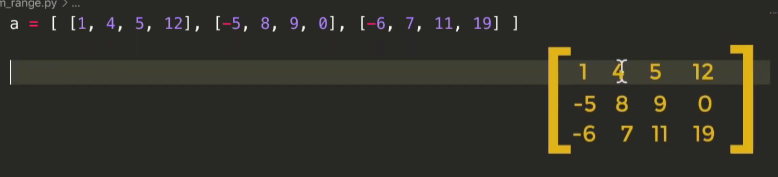

In [5]:
a=(3)
b=(3,)
c=np.array([1,2,3,4])

print(type(a))
print(type(b))
print(c.shape)

#hence to represent a shape in tuple form we need (3,) so that is a tuple and not a int

<class 'int'>
<class 'tuple'>
(4,)


### Model

$ W \in R^{Dx1}$  is a vector of parameters , D is polynomial degree  
$ \phi \in R^{NxD}$ N is size of dataset

$ y = \phi.W  \in R^{Nx1} $  
We need to create method to compute the polynomial value. This method takes set $ X = \{x_n\}^{N}_{n=1} $ (dataset) and $ w = \{w_m\}^{M+1}_{m=1} $ (parameters) and then compute the the corresponding output value or polynomial values $ y_n $ for $ x_n $

Example  
let the function polynomail be $ y = f(W,X) $ be $ y = w_0 + w_1.x + w_2.x^2 ...(D =2) $



In [6]:
def polynomial(X,W):
    dm = [W[i]*(X**i) for i in range(np.shape(W)[0])]
    """ 
    dm = []
    
    for i in range(len(X)):
        sum = 0;
        for j in range(len(W)):
            sum += W[j]*(X[i]**j)
        dm.append(sum)

    return dm
    """
    return np.sum(dm,axis=0) # axis = 0 means sum along the columns, axis = 1 means sum along the rows

In [7]:
#testing polynomial function
W = np.array([1,3,2])
X= np.array([1,2,3,-4])
p=polynomial(X,W)
print("Polynomial output : ",p)


# dm = [1*pow(1,0) + 3*pow(1,1) + 2*pow(1,2), 
#         1*pow(2,0) + 3*pow(2,1) + 2*pow(2,2), 
#         1*pow(3,0) + 3*pow(3,1) + 2*pow(3,2), 
#         1*pow(-4,0) + 3*pow(-4,1) + 2*pow(-4,2)]

# dm = [6+0, 15+0, 28+0, 21+0] col is 0 since axis is 0



Polynomial output :  [ 6 15 28 21]


### Mean Squared Error

To measure how good our model is we should use the cost function called Mean Squared Error  
$ E = \frac{1}{2N}||\bar{y}-y||^2_2   ... (\bar{y} = y_{pred},\; y = y_{true})$

$ || x ||_2 =  \sqrt{\sum_{n=1}^{N} x_n^2} $ this is norm2



In [8]:
def mse(y_pred,y_true):
    # y_pred : predicted output vector (Nx1)
    # y_true : true output vector (Nx1)
    
    N = y_pred.shape[0] # a = ([1,2,3])  a.shape = (3,)  a.shape[0] = 3

    error = np.sum((y_pred-y_true)**2)/(2*N)

    return error

In [9]:
y_pred = p
y_real = [7, 14, 22, 30]

print("Y predicted", y_pred)
print()
print("Y real", y_real)
print()
print("Mean Squared Error", mse(y_pred, y_real))

Y predicted [ 6 15 28 21]

Y real [7, 14, 22, 30]

Mean Squared Error 14.875


### Minimize the cost function

![Screenshot_20260416_224158_Samsung Notes.jpg](<attachment:Screenshot_20260416_224158_Samsung Notes.jpg>)
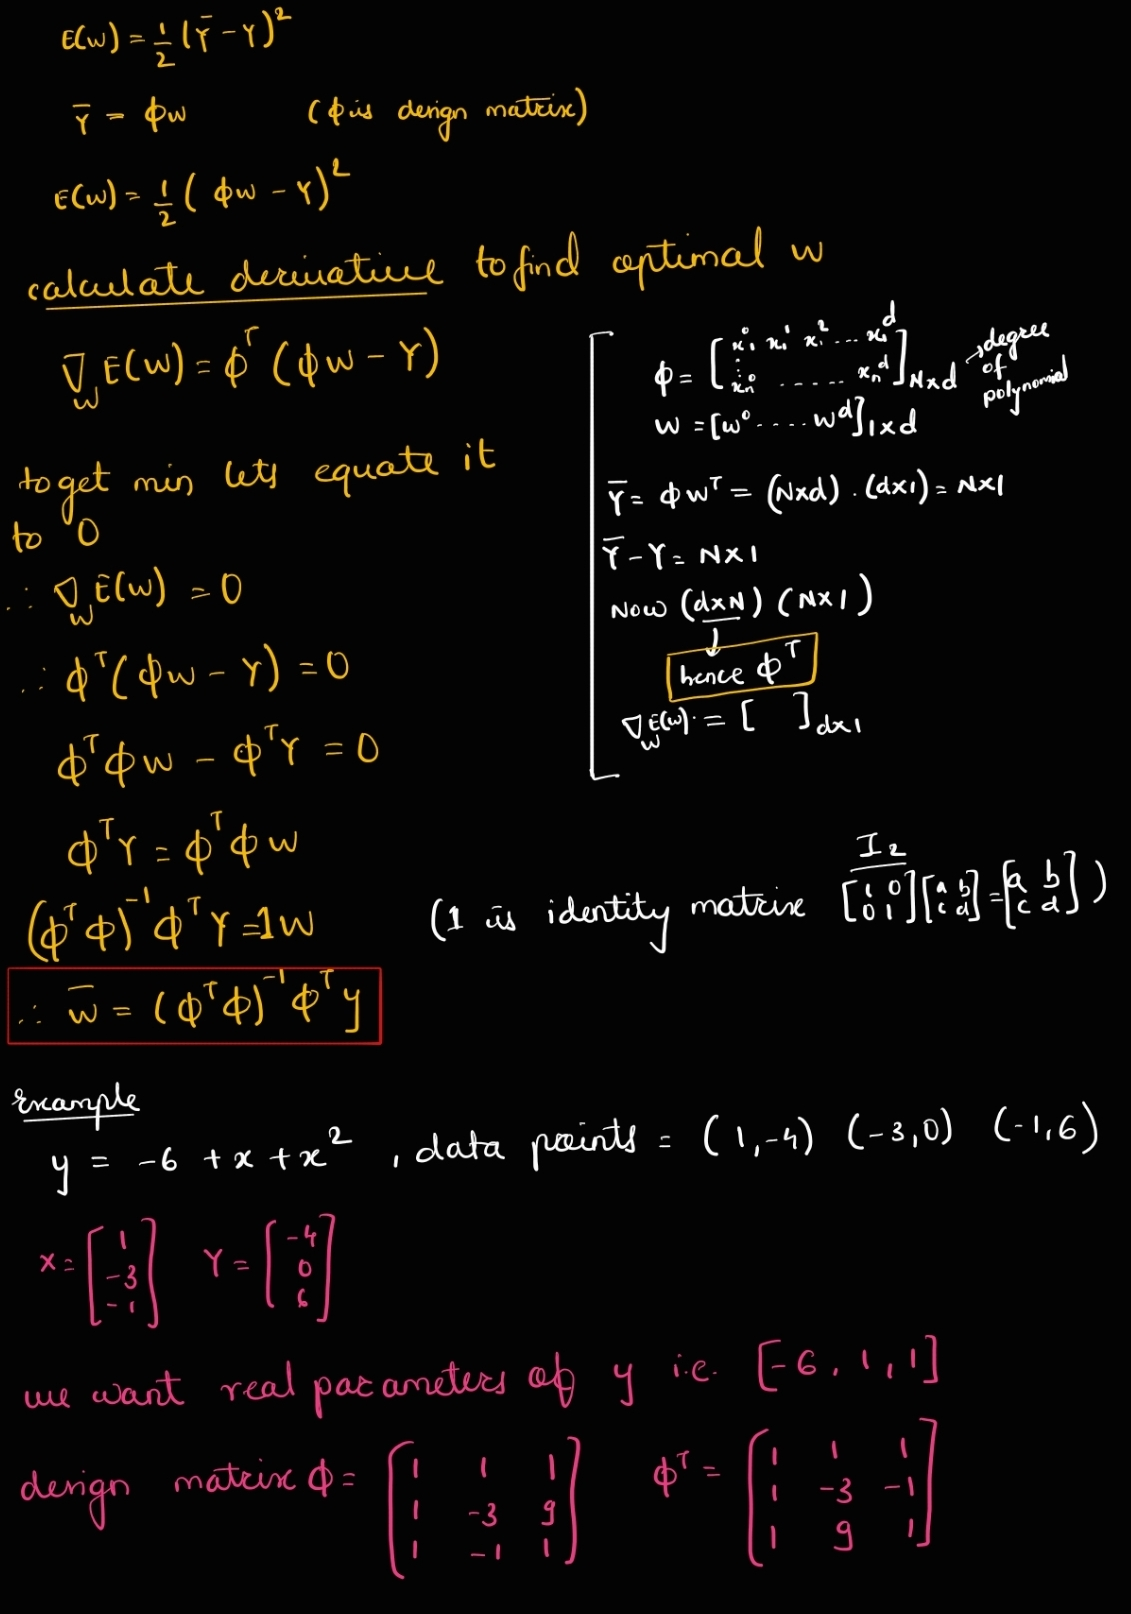

![Screenshot_20260416_224511_Samsung Notes.jpg](<attachment:Screenshot_20260416_224511_Samsung Notes.jpg>)
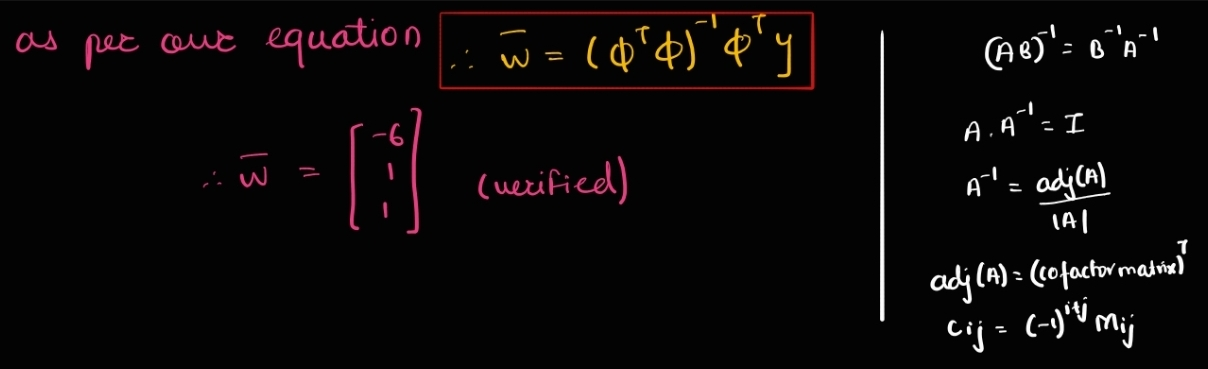

x_train = np.array([[1], [-3], [-1]])

np.array([x**i for i in range(3)])

i=0

x**0

[[1],

 [1],

 [1]]

 i=1

 [[1],

 [2],

 [3]]

 i=2
 [[1],[4],[9]]

 now put them in array 
 
 [

 [[1], [1], [1]],
 
 [[1], [2], [3]],
 
 [[1], [4], [9]]

]

shape is (3,3,1)
meaning 
3 layers 
each layer is 3 x 1 


after transpose it becomes 

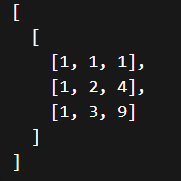

shape = (1,3,3)

In [11]:
# trying to transpose a 3 matrix 
x = np.array([[1], [-3], [-1]])

dm = design_matrix(x,2)
print(dm)
print(dm.shape)
print(dm[0])
print(dm[0].shape)

[[[ 1  1  1]
  [ 1 -3  9]
  [ 1 -1  1]]]
(1, 3, 3)
[[ 1  1  1]
 [ 1 -3  9]
 [ 1 -1  1]]
(3, 3)


![Screenshot_20260422_223933_Samsung Notes.jpg](<attachment:Screenshot_20260422_223933_Samsung Notes.jpg>)
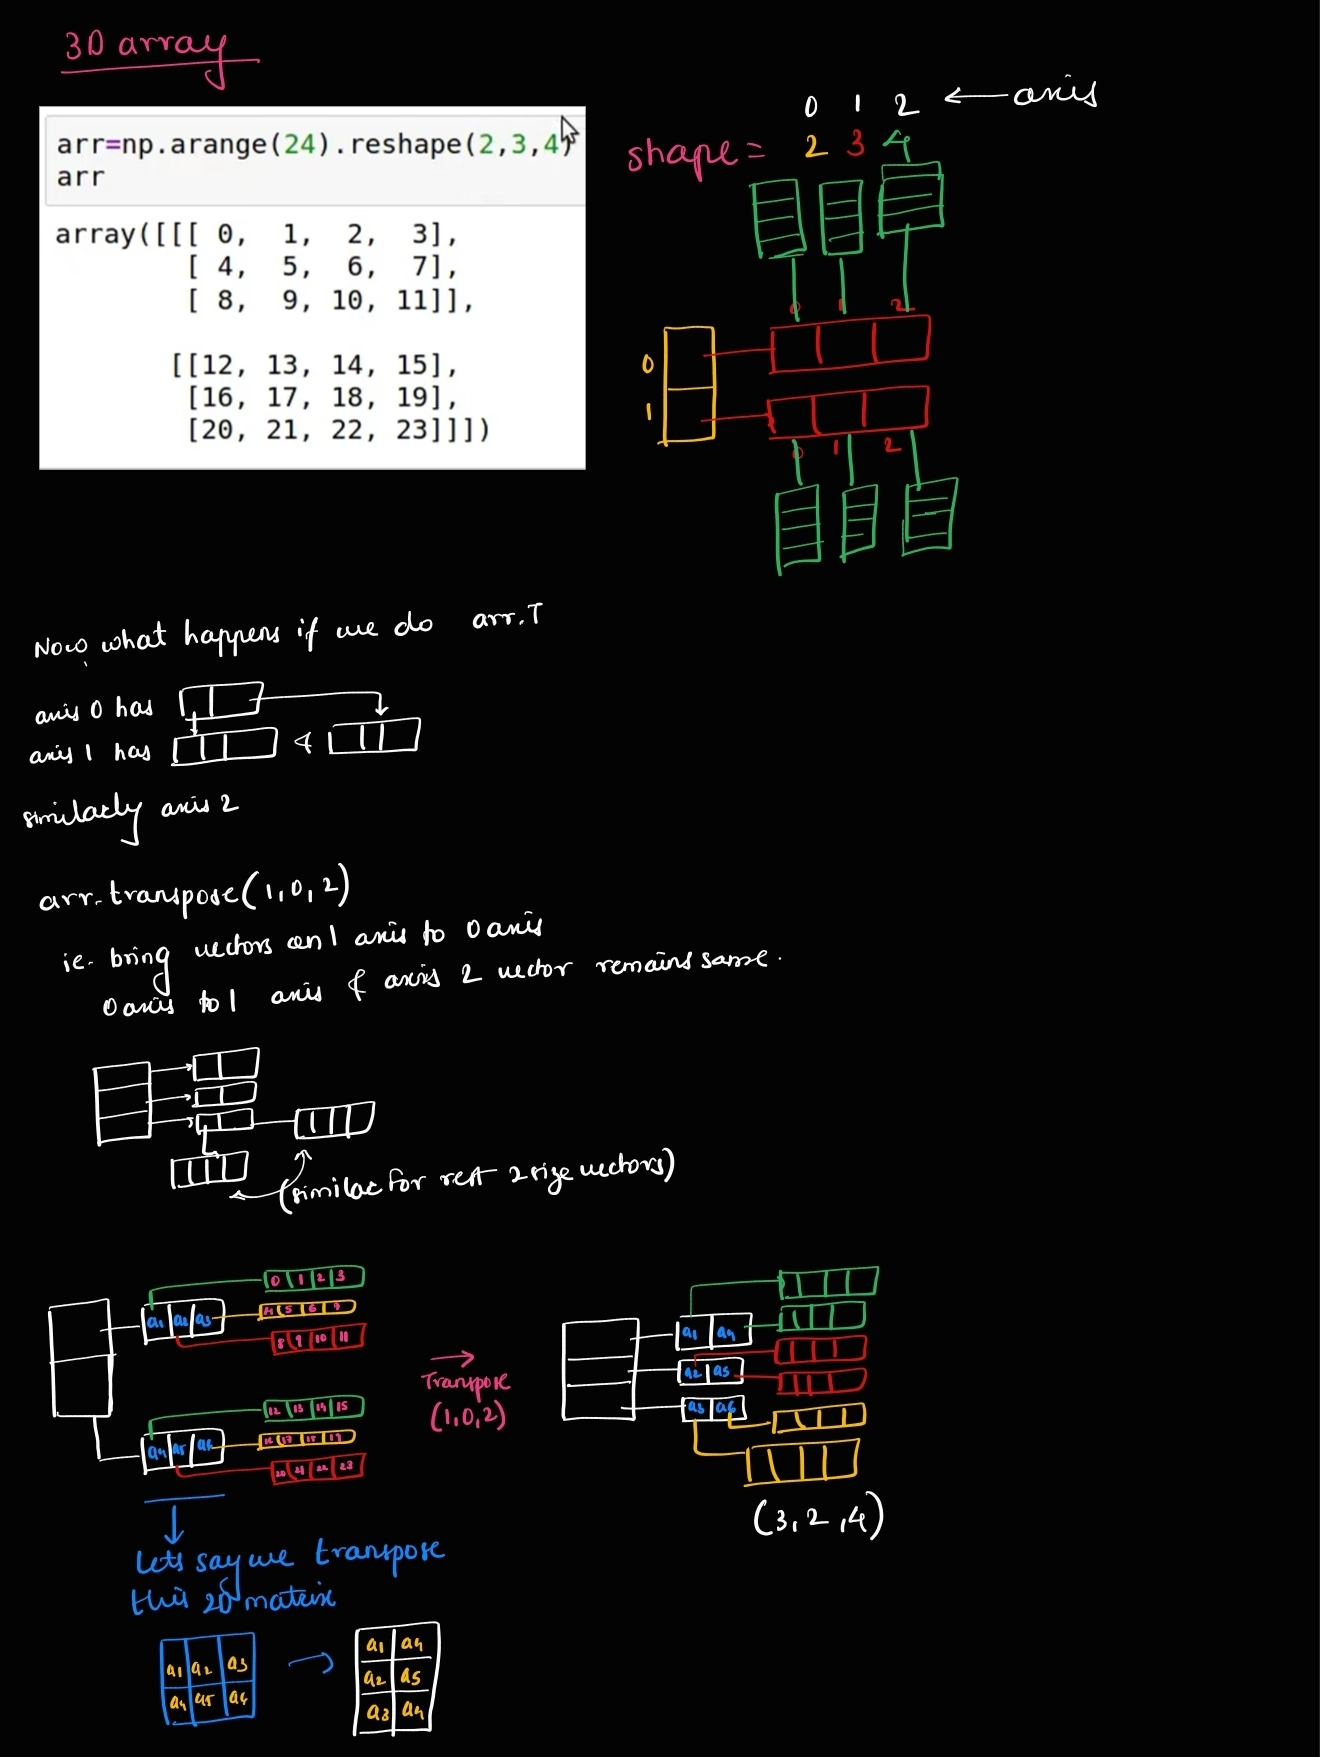

In [18]:
def least_squares(x_train,y_train,M):
    '''
    x_train : vector of input values (Nx1)
    y_train : vector of output values (Nx1)
    M : degree of the polynomial 0 1 2 3 4 5
   return tuple (w,error) where w is are best polynomial parameters and error is mse
    '''
    dm = design_matrix(x_train,M)
    print(dm)
    print(dm.shape)
    w=np.linalg.inv(dm.T @ dm) @ dm.T @ y_train
    y_pred = polynomial(x_train,w)

    error = mse(y_pred,y_train)
    
    error = np.asscaler(error) #This used to convert a NumPy array (with one element) into a Python scalar (like float or int).
    return (w,error)

In [15]:
x_train = np.array([[1], [-3], [-1]])
y_train = np.array([[-4], [0], [-6]])
print(x_train.shape)
print("X coordinates of our training data: \n", x_train)
print()
print("Y coordinates of our training data: \n", y_train)
print()
w = least_squares(x_train, y_train, 2)
print("Estimated parameters w: \n", w[0])

(3, 1)
X coordinates of our training data: 
 [[ 1]
 [-3]
 [-1]]

Y coordinates of our training data: 
 [[-4]
 [ 0]
 [-6]]

[[[ 1  1  1]
  [ 1 -3  9]
  [ 1 -1  1]]]
(1, 3, 3)


ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 3 is different from 1)